# 1 · Univariate MMAR: the baseline model

SPMO · VOO · 256 trading days

This notebook builds the single-series model used throughout the repository. It introduces the volatility cascade and standardized Student-$t$ innovations, trains one amortized posterior estimator, validates it on simulated data, and applies it to posterior predictive checks and rolling tail risk. The later notebooks reuse this model for screening, then extend it to joint assets and signed memory.

In [1]:
from pathlib import Path

import bayesflow as bf

from mmar import statistics as stats, viz
from mmar.data import load_market_returns

from mmar import univariate as model
from mmar.viz import univariate as plots

INFO:bayesflow:Multiple Keras-compatible backends detected (JAX, PyTorch, TensorFlow). Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [2]:
TICKERS = ("SPMO", "VOO")
FIGURES_DIR = Path("figures/univariate")
CHECKPOINT_DIR = Path("checkpoints/univariate")

viz.configure_plot_style()

## 1. Model specification

For one asset, the daily simple return is

$$r_t = \mu + \bar\sigma\sqrt{\theta_t(q)}\,\varepsilon_t,
\qquad \varepsilon_t=z_t\sqrt{(\nu-2)/U_t},$$
$$z_t\overset{\mathrm{iid}}{\sim}N(0,1),\qquad
U_t\overset{\mathrm{iid}}{\sim}\chi^2_\nu,\qquad z_t\perp U_t.$$

Here $\mu$ is daily drift, $\bar\sigma$ is the baseline RMS scale, and $\theta_t(q)$ is a positive trading-time increment normalized to average one within the 256-day window. The cascade parameter $q$ controls its contrast, while $\nu>2$ controls tail thickness. The variable $z_t$ is the Gaussian seed and $U_t$ is its independent chi-square mixing variable; together they make $\varepsilon_t$ a Student-$t$ innovation with mean zero and variance one. Returns are independent but heteroskedastic conditional on the cascade; after averaging over the random cascade they are not IID.

### Cascade construction

The animation shows the recursive binomial cascade that produces eight 32-day volatility blocks, followed by a random circular phase shift used by the simulator.

![A binomial cascade splits into eight 32-day volatility blocks, then receives a random circular shift.](gifs/fractal_cascade.gif)

In [3]:
model.prior_table(model.PRIOR)

,prior,meaning
parameter,,
mu,"Normal(0, 0.0015²)",Daily drift
sigma_bar,"Uniform(0.005, 0.025)",Baseline RMS return scale
q,"Uniform(0.52, 0.9)",Cascade contrast and volatility intermittency
nu,"2 + exp(Uniform(log(0.05), log(10)))",Student-t degrees of freedom and tail thickness


In [4]:
observed_returns = load_market_returns(TICKERS)
observed_window = observed_returns.tail(model.WINDOW)

## 2. Prior predictive checks

Before fitting any data, simulations test whether the priors generate plausible turbulence, marginal returns, and maximum drawdowns. These checks also make the separate roles of $q$ and $\nu$ visible.

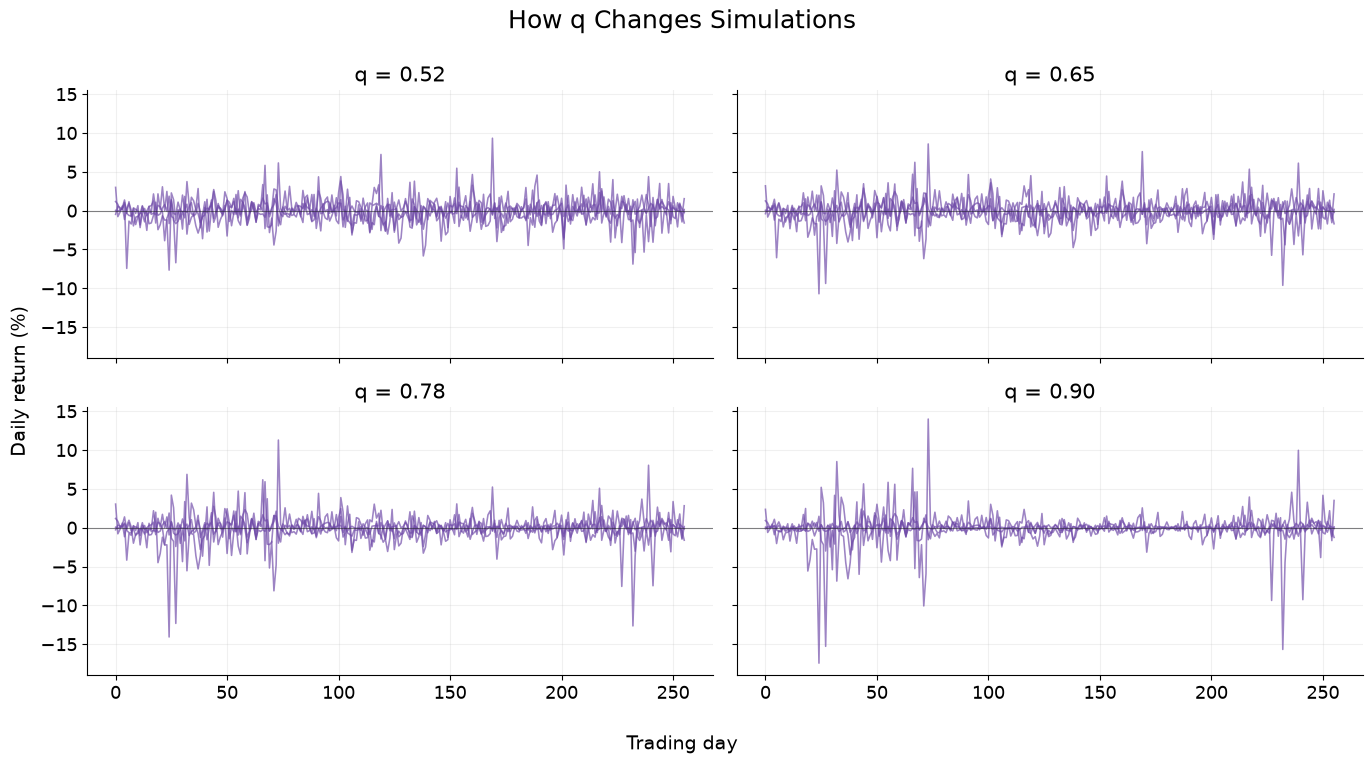

In [5]:
prior_simulations = model.simulate(3_000, seed=42, prior=model.PRIOR)
prior_returns = prior_simulations["returns"]

fig = plots.plot_q_turbulence(model.q_scenarios((0.52, 0.65, 0.78, 0.90), seed=42))
_ = viz.save_figure(fig, "01_prior_q_turbulence.png", FIGURES_DIR)

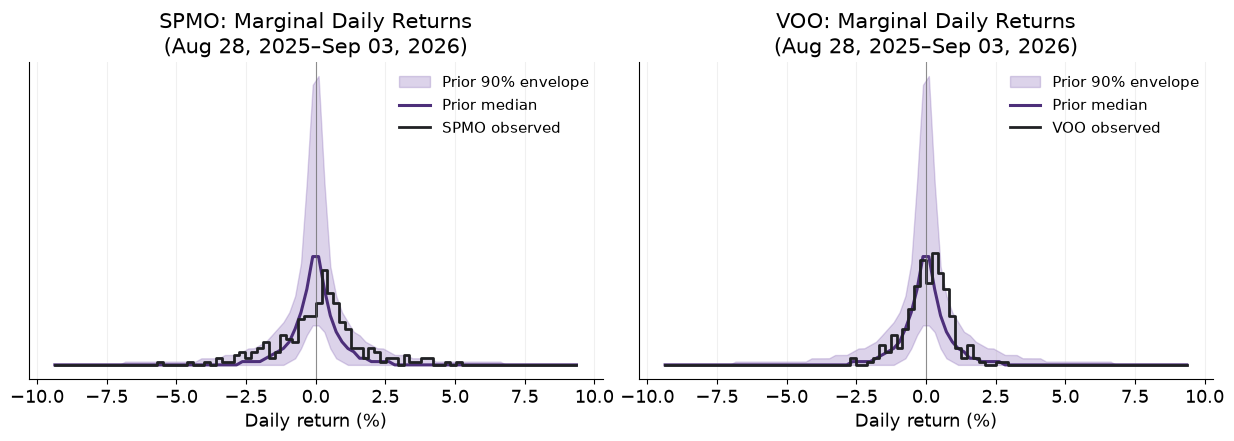

In [6]:
fig = plots.plot_marginal_return_histograms(100 * prior_returns, 100 * observed_window, tickers=TICKERS)
_ = viz.save_figure(fig, "02_prior_marginal_returns.png", FIGURES_DIR)

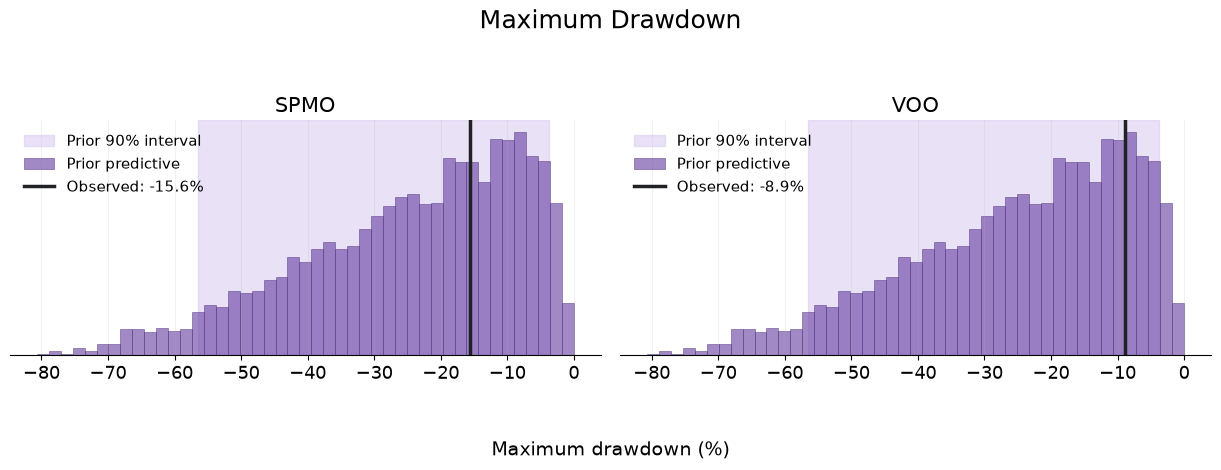

In [7]:
prior_stats = stats.statistics(prior_returns)
observed_stats = stats.statistics(observed_window.to_numpy().T)
observed_stats.index = TICKERS

fig = plots.plot_max_drawdown_checks(prior_stats, observed_stats, tickers=TICKERS)
_ = viz.save_figure(fig, "03_prior_max_drawdown.png", FIGURES_DIR)

In [8]:
envelope = stats.pushforward_envelope_table(prior_stats, observed_stats).rename(
    columns={"observed_pct": "observed", "prior_q05_pct": "prior_q05", "prior_q95_pct": "prior_q95"})
envelope.style.format(precision=2)

,ticker,stat,observed,prior_q05,prior_q95,inside_prior_90pct_band
0,SPMO,mean_pct,0.10,-0.29,0.28,True
1,SPMO,volatility_pct,1.53,0.41,2.40,True
2,SPMO,avg_abs_return_pct,1.10,0.27,1.53,True
3,SPMO,q01_pct,-3.63,-6.66,-0.97,True
4,SPMO,q05_pct,-2.60,-3.40,-0.43,True
5,SPMO,q95_pct,2.72,0.44,3.41,True
6,SPMO,q99_pct,4.02,1.03,6.59,True
7,SPMO,es05_pct,-3.35,-5.58,-0.88,True
8,SPMO,max_drawdown_pct,-15.64,-56.48,-3.71,True
9,SPMO,terminal_wealth,1.27,0.46,2.03,True


## 3. Simulation-based training data

`model.simulate` is the model's simulation entry point: each call returns parameters together with their 256-day return paths as a dictionary.

In [9]:
training_simulations = model.simulate(100_000)
validation_simulations = model.simulate(500)

## 4. Amortized inference

The adapter maps bounded parameters to the estimator and maps posterior draws back to their original units; $\mu$ remains unbounded.

In [10]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .constrain("sigma_bar", lower=model.PRIOR.sigma_low, upper=model.PRIOR.sigma_high)
    .constrain("q", lower=model.PRIOR.q_low, upper=model.PRIOR.q_high)
    .constrain("nu", lower=model.PRIOR.nu_low, upper=model.PRIOR.nu_high)
    .concatenate(model.PARAMETER_NAMES, into="inference_variables")
    .as_time_series("returns")
    .rename("returns", "summary_variables")
)

In [11]:
# This network will embed the time series into informative summary vectors
summary_network = bf.networks.FusionTransformer(dropout=0.1)

# This network will sample from the posterior given the output of the summary net
inference_network = bf.networks.CouplingFlow(transform="spline", depth=4)

In [12]:
workflow = bf.BasicWorkflow(
    adapter=adapter,
    summary_network=summary_network,
    inference_network=inference_network,
    standardize="all",
    checkpoint_filepath=CHECKPOINT_DIR,
    save_best_only=True
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To restore the approximator from the checkpoint, call workflow.load_approximator() or pass restore=True to the workflow constructor.


In [10]:
history = workflow.fit_offline(
    data=training_simulations, 
    validation_data=validation_simulations, 
    epochs=60, 
    batch_size=128
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - loss: 4.3586 - val_loss: 3.2882
Epoch 2/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.6832 - val_loss: 2.2700
Epoch 3/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.3198 - val_loss: 1.9469
Epoch 4/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.1241 - val_loss: 1.8835
Epoch 5/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.0140 - val_loss: 1.7407
Epoch 6/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.9307 - val_loss: 1.8748
Epoch 7/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.8325 - val_loss: 1.6855
Epoch 8/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.7460 - val_loss: 1.4870
Epoch 9/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.6405 - val_loss: 1.3835
Epoch 10/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.5252 - val_loss: 1.2848
Epoch 11/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.4569 - val_loss: 1.1700
Epoch 12/60
782/782 ━━━━━━━━━━━━━━━━━━━━

INFO:bayesflow:Training completed in 9.37 minutes.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'checkpoints/univariate/model.keras'.
To restore it:
Via the workflow: workflow.load_approximator()
Standalone: approximator = keras.saving.load_model("checkpoints/univariate/model.keras")


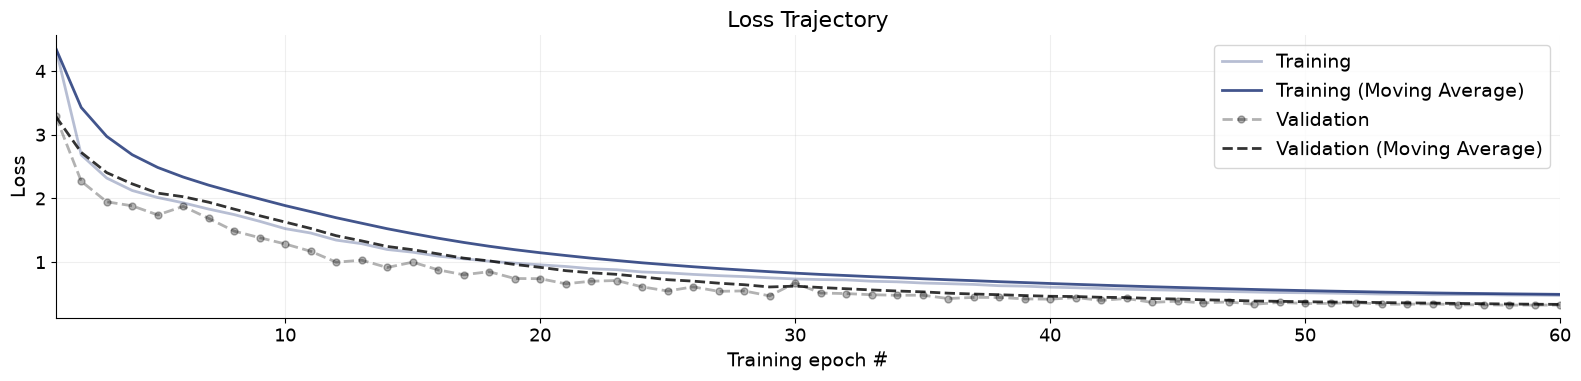

In [11]:
fig = bf.diagnostics.loss(history)
_ = viz.save_figure(fig, "04_training_loss.png", FIGURES_DIR)

## 5. Parameter recovery and calibration

Fresh simulations provide known ground truth. Recovery tests point estimation; simulation-based calibration tests whether posterior uncertainty has the advertised coverage.

In [13]:
# Loads the best approximator internally
workflow.load_approximator()

INFO:bayesflow:Approximator restored from 'checkpoints/univariate/model.keras'.


In [14]:
test_simulations = model.simulate(300, seed=555)

Warm sampling on 300 new series should take around ~ 0.25 seconds on a 2022-old GPU.

In [16]:
estimates = workflow.sample(conditions=test_simulations, num_samples=1000)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.25 seconds.


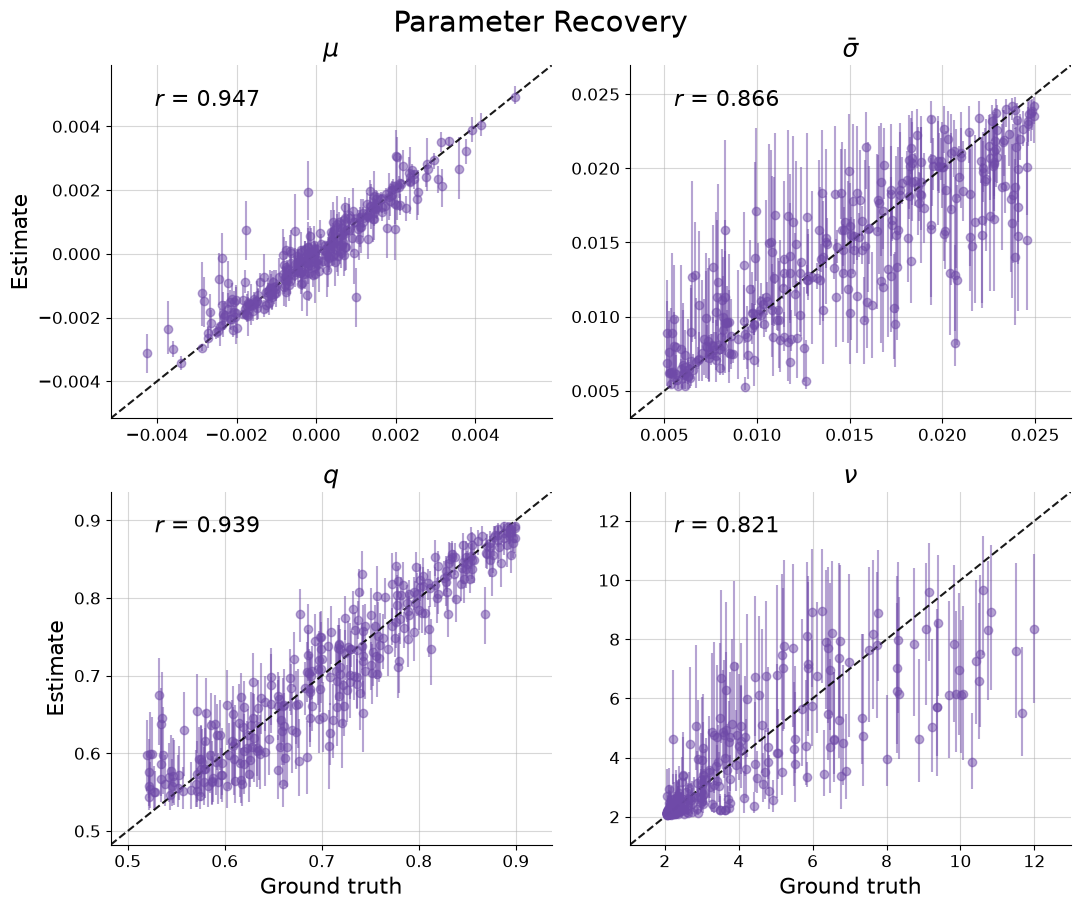

In [ ]:
fig = viz.plot_recovery(estimates, test_simulations, model.PARAMETER_LABELS)
_ = viz.save_figure(fig, "05_parameter_recovery.png", FIGURES_DIR)

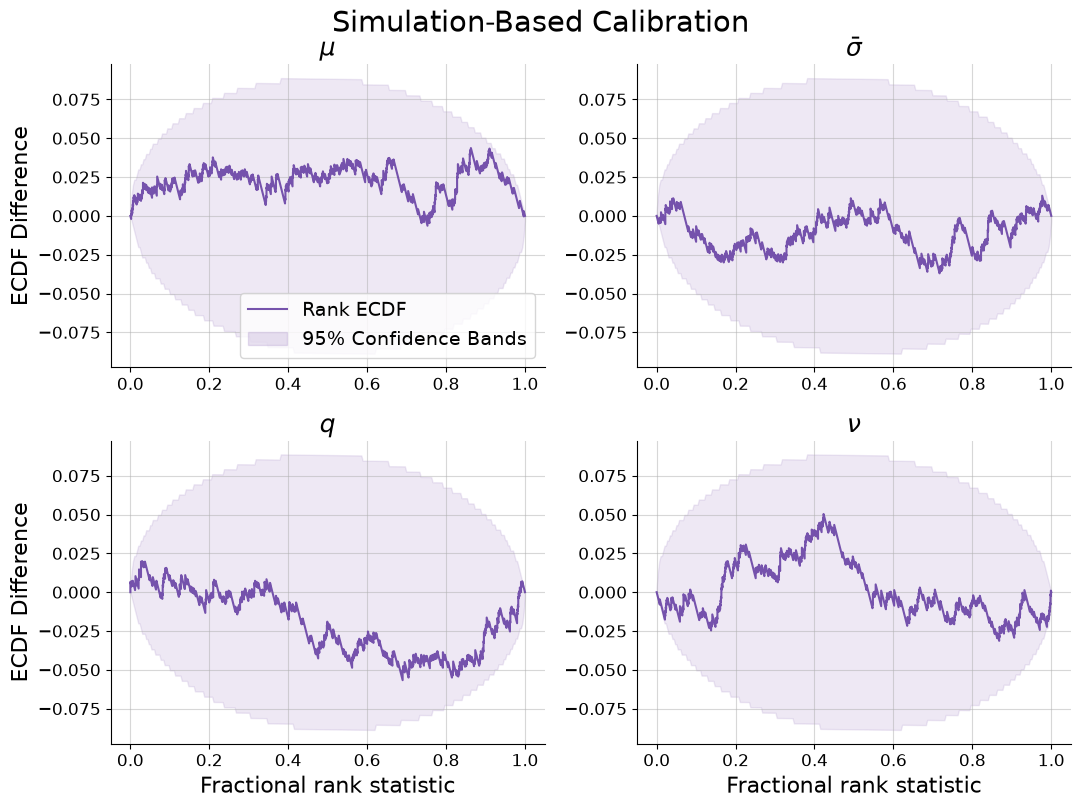

In [ ]:
fig = viz.plot_calibration(estimates, test_simulations, model.PARAMETER_LABELS)
_ = viz.save_figure(fig, "06_simulation_based_calibration.png", FIGURES_DIR)

We can also easily obtain a per-parameter numerical summary:

In [22]:
table = workflow.compute_default_diagnostics(test_simulations, samples=estimates)
table

,mu,sigma_bar,q,nu
NRMSE,0.243392,0.421019,0.304520,0.289872
Log Gamma,1.237576,4.463649,2.335364,1.343439
Calibration Error,0.007105,0.005175,0.033421,0.020351
Posterior Contraction,0.948366,0.779216,0.898413,0.927779


## 6. Posterior predictive checks

Fresh 256-day resimulations: predicted maximum drawdown, 68% and 92% wealth intervals, and marginal return histograms.

In [20]:
observed_windows = observed_window.to_numpy().T
posterior = workflow.sample(conditions={"returns": observed_windows[..., None]}, num_samples=600)
posterior = model.stack_samples(posterior)

posterior_paths = model.posterior_resimulations(posterior)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.07 seconds.


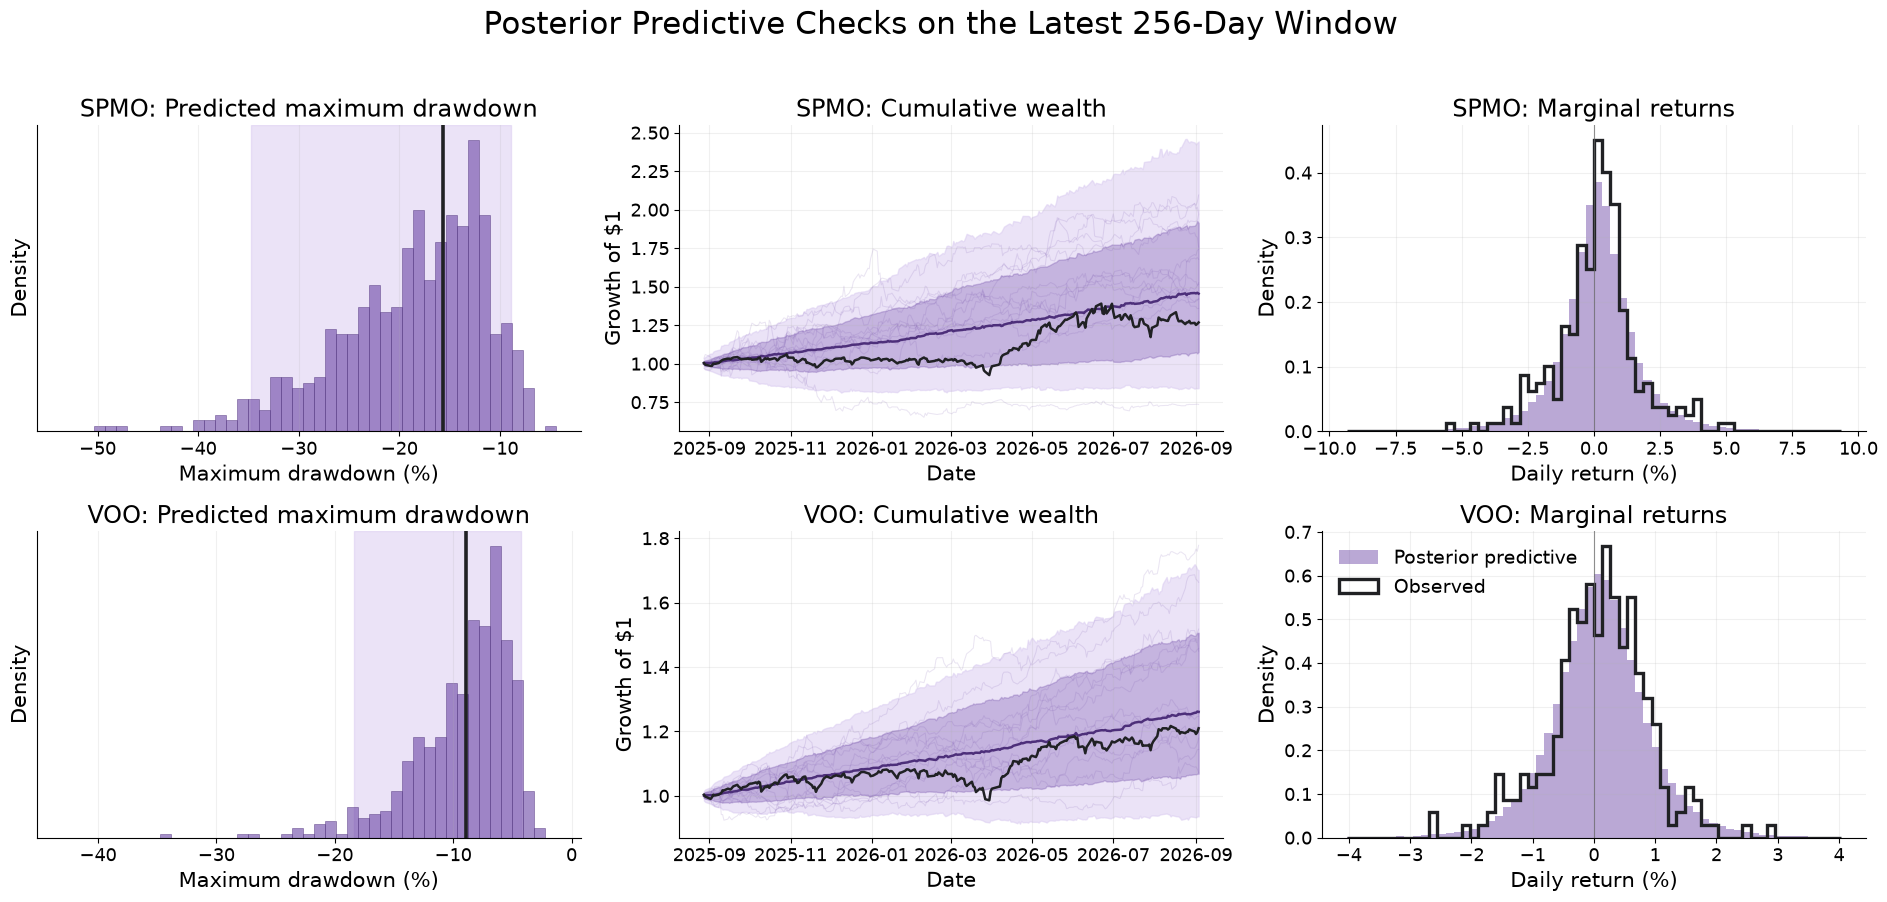

In [ ]:
fig = plots.plot_posterior_predictive_checks(
    posterior_paths, observed_windows, [observed_window.index] * 2, tickers=TICKERS,
)

_ = viz.save_figure(fig, "07_posterior_predictive_checks.png", FIGURES_DIR)

## 7. Amortized risk estimation

We will look at two popular metrics:

- **Value-at-Risk (VaR):** the loss threshold exceeded by only 5% of posterior-predictive outcomes.
- **Expected shortfall (ES):** the average loss within that worst 5%; it measures tail severity beyond VaR.

Let $\mathcal D_t=(r_{t-255},\ldots,r_t)$ denote the observed trailing window. The model averages the $h$-day compounded return over its parameter posterior:

$$R_{t,h}=\prod_{j=1}^{h}(1+\widetilde r_{t+j})-1, \qquad p(R_{t,h}\mid\mathcal D_t)=\int p(R_{t,h}\mid\boldsymbol\phi)\,p(\boldsymbol\phi\mid\mathcal D_t)\,d\boldsymbol\phi.$$

Writing loss as $L_{t,h}=-R_{t,h}$, the reported posterior-predictive risk measures are

$$\operatorname{VaR}_{95}^{\mathrm{loss}}(\mathcal D_t)=Q_{0.95}(L_{t,h}\mid\mathcal D_t)=-Q_{0.05}(R_{t,h}\mid\mathcal D_t),$$

$$\operatorname{ES}_{95}^{\mathrm{loss}}(\mathcal D_t)=\mathbb{E}[L_{t,h}\mid L_{t,h}\geq\operatorname{VaR}_{95}^{\mathrm{loss}},\mathcal D_t]=-\mathbb{E}[R_{t,h}\mid R_{t,h}\leq Q_{0.05}(R_{t,h}\mid\mathcal D_t),\mathcal D_t].$$

Here $h=20$ trading days. Bands show variation across posterior parameters (epistemic uncertainty) plus simulation noise (aleatoric uncertainty).

**Historical simulation** At every `as_of` date, it takes the trailing 256 observed daily returns and compounds every overlapping 20-day block, giving $256-20+1=237$ historical outcomes. Historical VaR is minus their empirical 5th percentile; historical ES is minus the mean of outcomes at or below that percentile.

MMAR VaR/ES can be higher because each window uses posterior predictive re-simulations and propagates parameter uncertainty, volatility clustering, and heavy-tail behavior. The overlapping historical outcomes are highly dependent and may contain few or no severe episodes. This makes historical simulation less responsive to plausible but unobserved tail events, although MMAR risk is not guaranteed to be higher in every window.

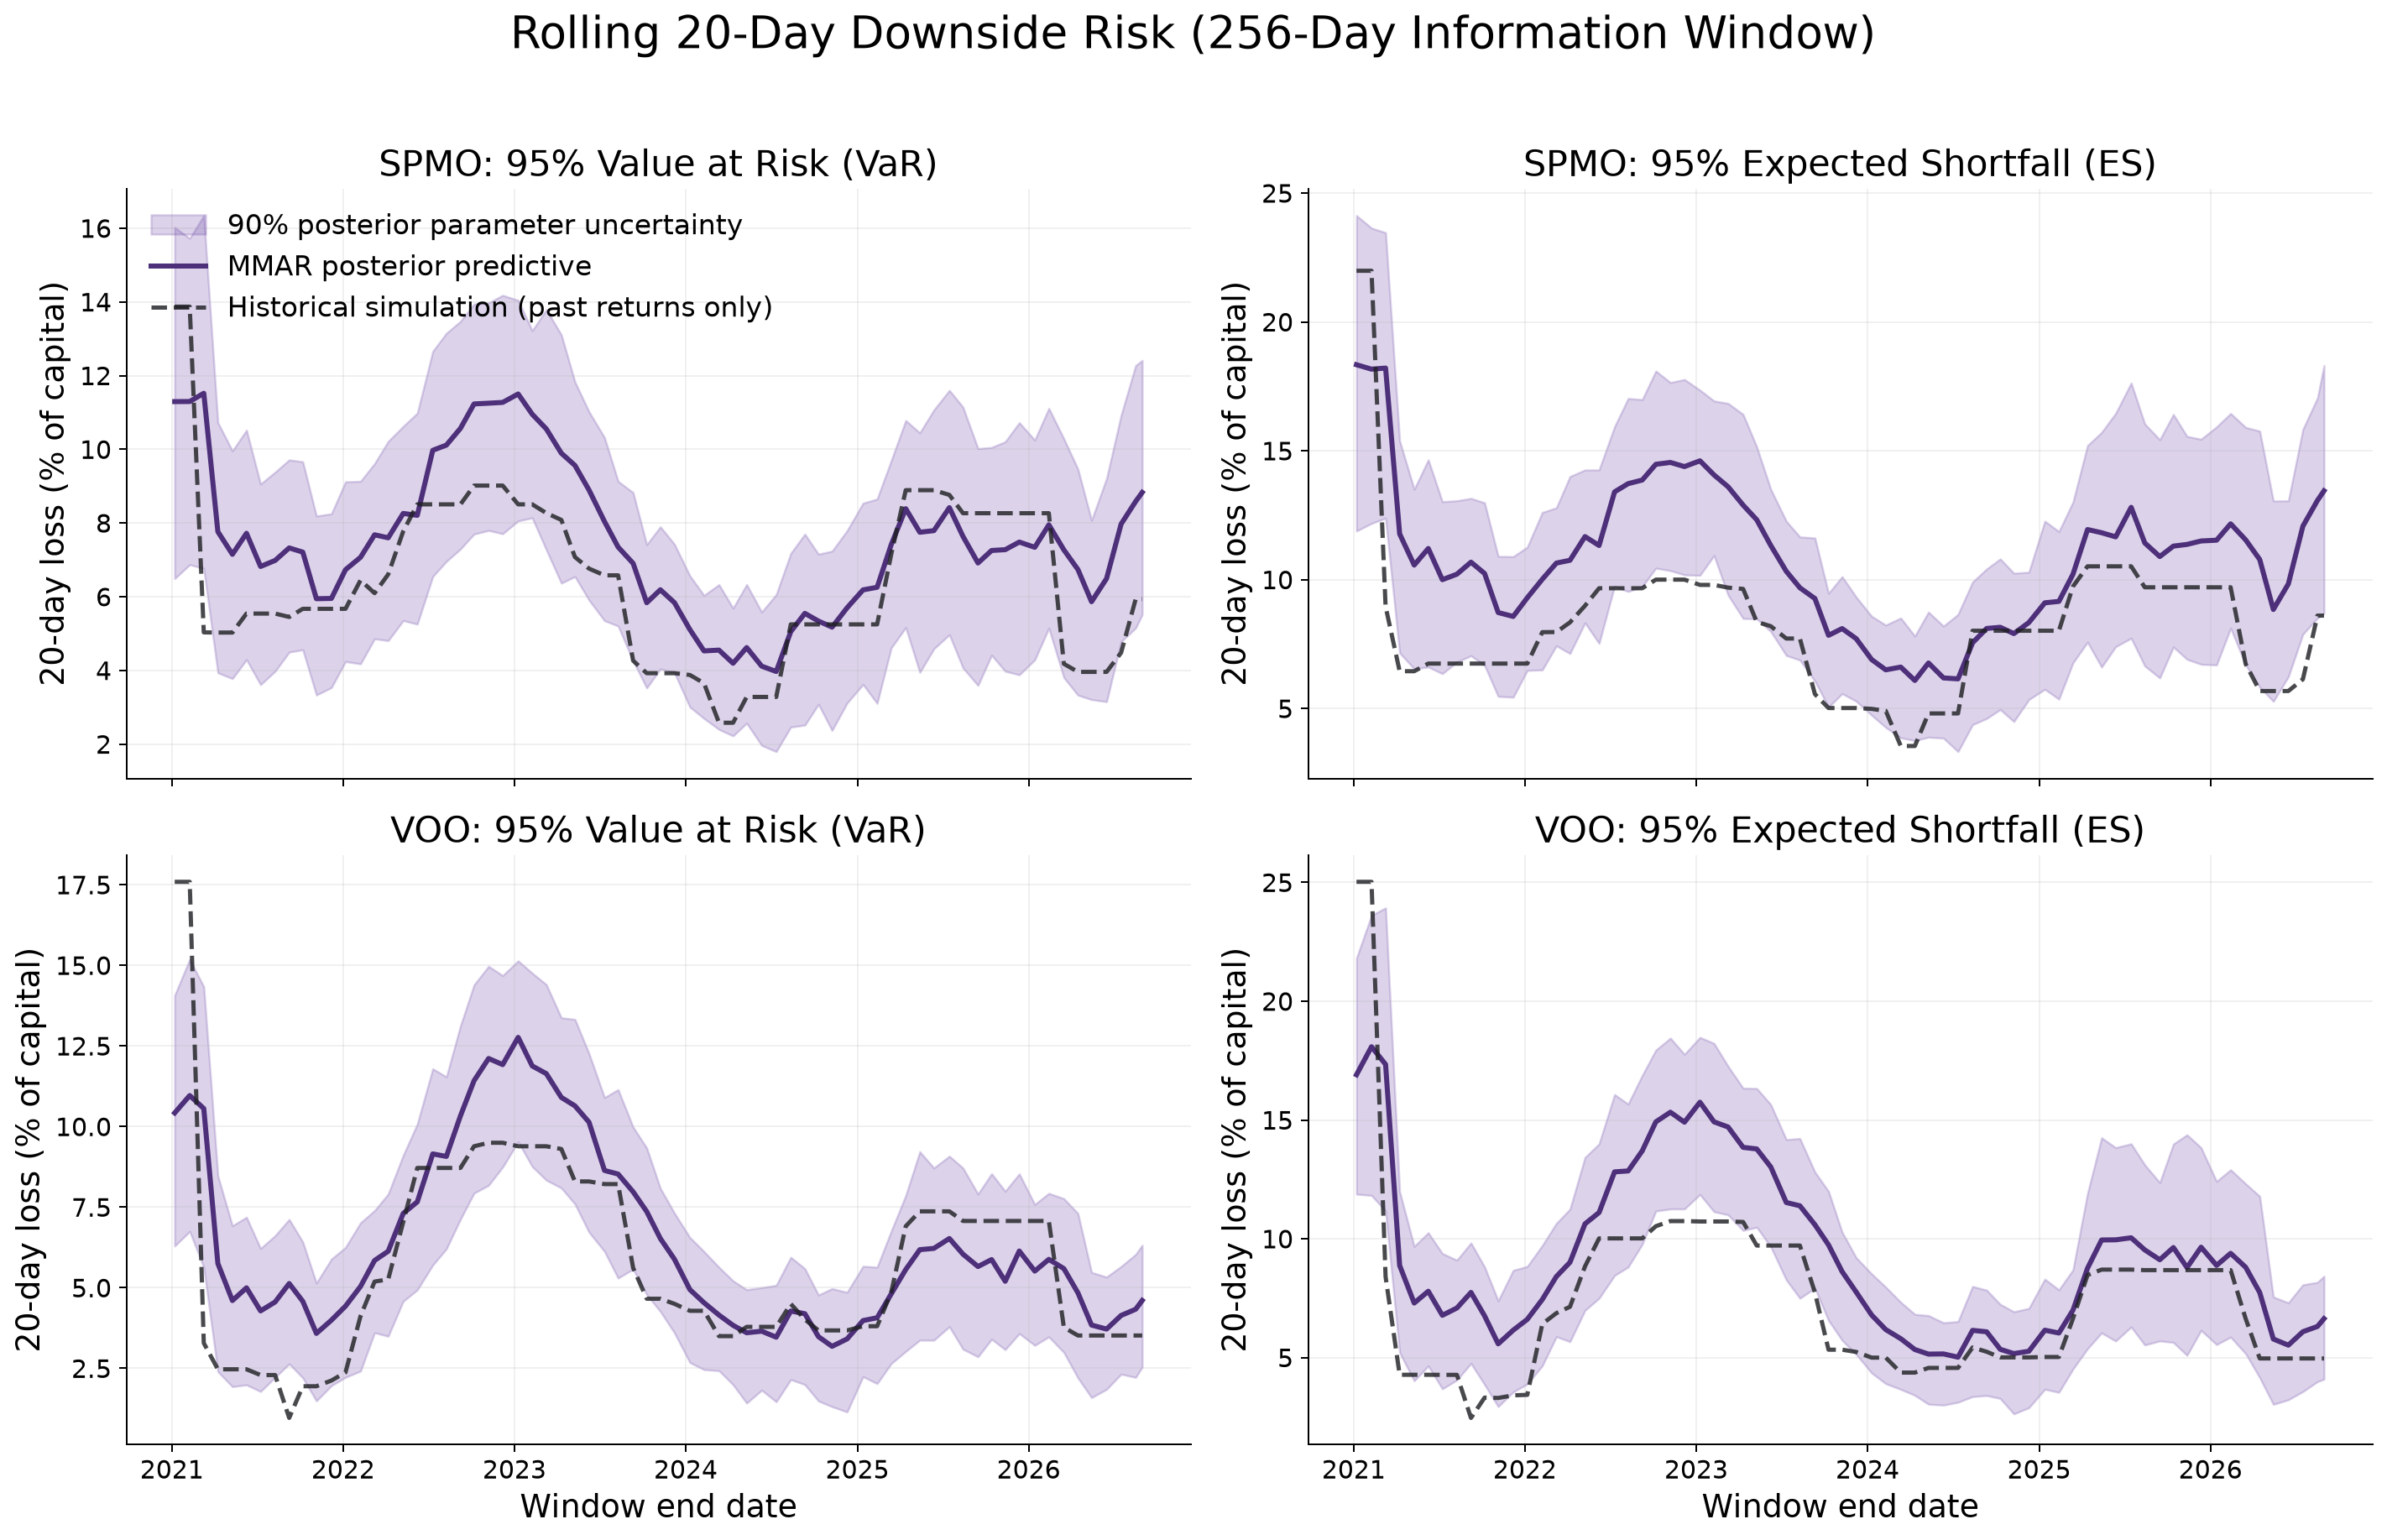

In [ ]:
# Create rolling windows and rolling posteriors
rolling_windows, rolling_metadata = model.rolling_return_windows(observed_returns, TICKERS, step=21)
rolling_posteriors = workflow.sample(conditions={"returns": rolling_windows}, num_samples=500)
rolling_posteriors = model.stack_samples(rolling_posteriors)

# Create risk paths and uncertainties
risk_table = model.posterior_risk_table(
    posterior_samples=rolling_posteriors, 
    metadata=rolling_metadata,
    observed_returns=observed_returns,
    horizon=20, 
    n_parameter_draws=160, 
    n_replications=192,
)

risk_table.to_csv(FIGURES_DIR / "rolling_risk.csv", index=False)

fig = plots.plot_rolling_risk(risk_table, tickers=TICKERS)
_ = viz.save_figure(fig, "08_rolling_var_es.png", FIGURES_DIR)

## 8. Deep ensembles

As an optional inference extension, the same simulator and adapter can train several posterior architectures. The normalizing flow, flow-matching model, and diffusion model below differ only in how they approximate the posterior; the four-parameter MMAR is unchanged.

In [19]:
workflow = bf.EnsembleWorkflow(
    inference_networks={
        "nf": bf.networks.CouplingFlow(depth=4, transform="spline"),
        "fm": bf.networks.FlowMatching(subnet_kwargs={"depth": (128,)*3}),
        "dm": bf.networks.DiffusionModel(subnet_kwargs={"depth": (128,)*3}),
    },
    summary_networks=bf.networks.FusionTransformer(),
    adapter=adapter,
    standardize="all"
)

In [20]:
history = workflow.fit_offline(
    data=training_simulations, 
    validation_data=validation_simulations,
    epochs=30,
    batch_size=128
)

INFO:bayesflow:EnsembleIndexedDataset: ensemble_size=3, batch_size=128, num_samples=100000, data_reuse=1.0 -> reduction_factor=1.00, window_size=100000, steps_per_epoch=782, drop_last=False. Overlap is enforced at the subdataset level (member-specific windows into the global index pool).
INFO:bayesflow:Fitting on dataset instance of EnsembleDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 62ms/step - dm/loss: 0.2579 - fm/loss: 0.9191 - loss: 4.1545 - nf/loss: 2.9774 - val_dm/loss: 0.3098 - val_fm/loss: 0.9654 - val_loss: 3.8047 - val_nf/loss: 2.5296
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - dm/loss: 0.2398 - fm/loss: 0.9631 - loss: 3.9520 - nf/loss: 2.7491 - val_dm/loss: 0.2386 - val_fm/loss: 0.7963 - val_loss: 3.0114 - val_nf/loss: 1.9765
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - dm/loss: 0.2298 - fm/loss: 0.8535 - loss: 3.5200 - nf/loss: 2.4367 - val_dm/loss: 0.2426 - val_fm/loss: 0.7846 - val_loss: 3.0147 - val_nf/loss: 1.9875
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - dm/loss: 0.1940 - fm/loss: 0.9137 - loss: 3.2198 - nf/loss: 2.1122 - val_dm/loss: 0.2667 - val_fm/loss: 0.8159 - val_loss: 3.1317 - val_nf/loss: 2.0491
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - dm/loss: 0.2094 - fm/loss: 0.8185 - loss: 3.0975 - nf/loss: 2.0696 - val_dm/loss: 0.2600 - val_fm/loss: 0.9625 -

INFO:bayesflow:Training completed in 14.03 minutes.


In [21]:
samples = workflow.sample(
    conditions=test_simulations, 
    num_samples=1000,
    batch_size=20,
    merge_members=False
)

Summarizing:   0%|          | 0/15 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/15 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/15 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/15 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/15 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/15 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 1.84 minutes.


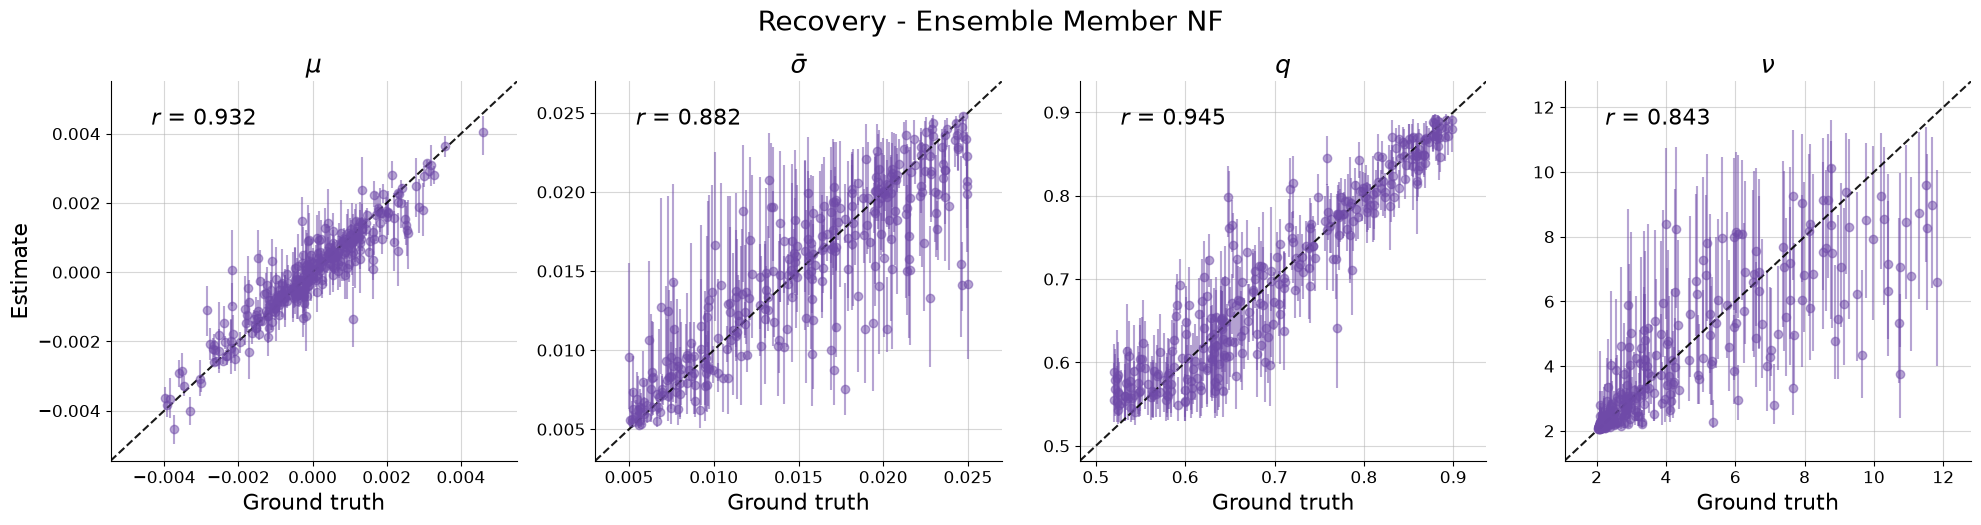

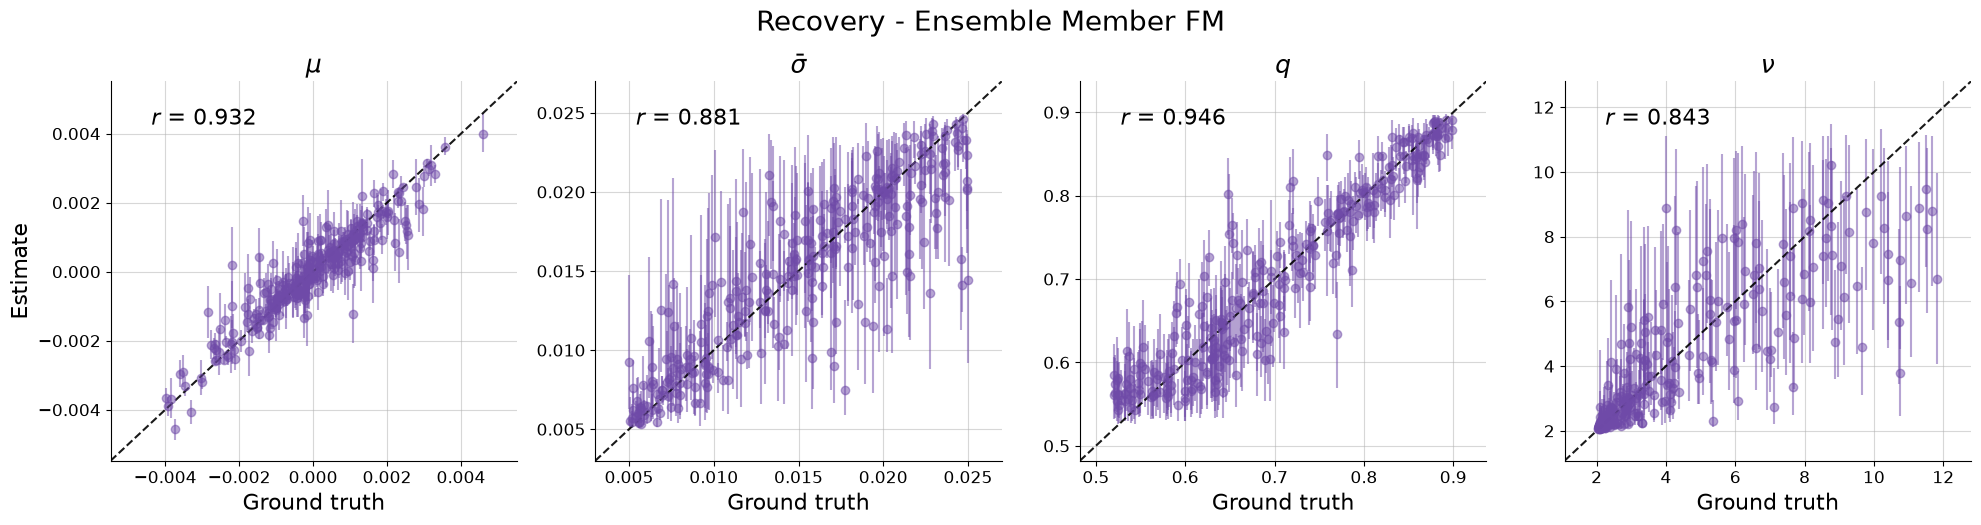

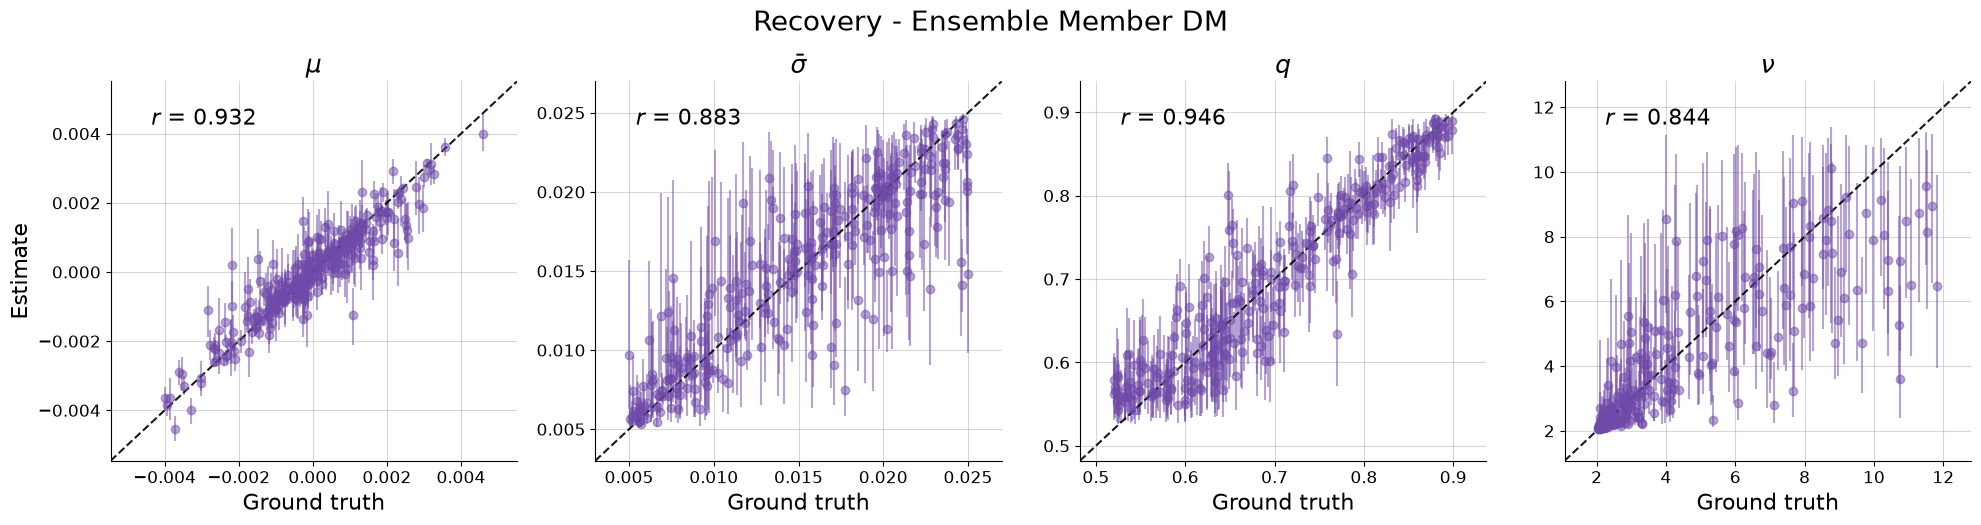

In [32]:
for k, v in samples.items():
    fig = bf.diagnostics.recovery(
        estimates=samples[k],
        targets=test_simulations,
        uncertainty_agg_kwargs={"prob": 0.68},
        color=viz.PREDICTION_PURPLE,
        variable_names=model.PARAMETER_LABELS
    )
    fig.suptitle(f"Recovery - Ensemble Member {k.upper()}", fontsize=20, y=1.05)

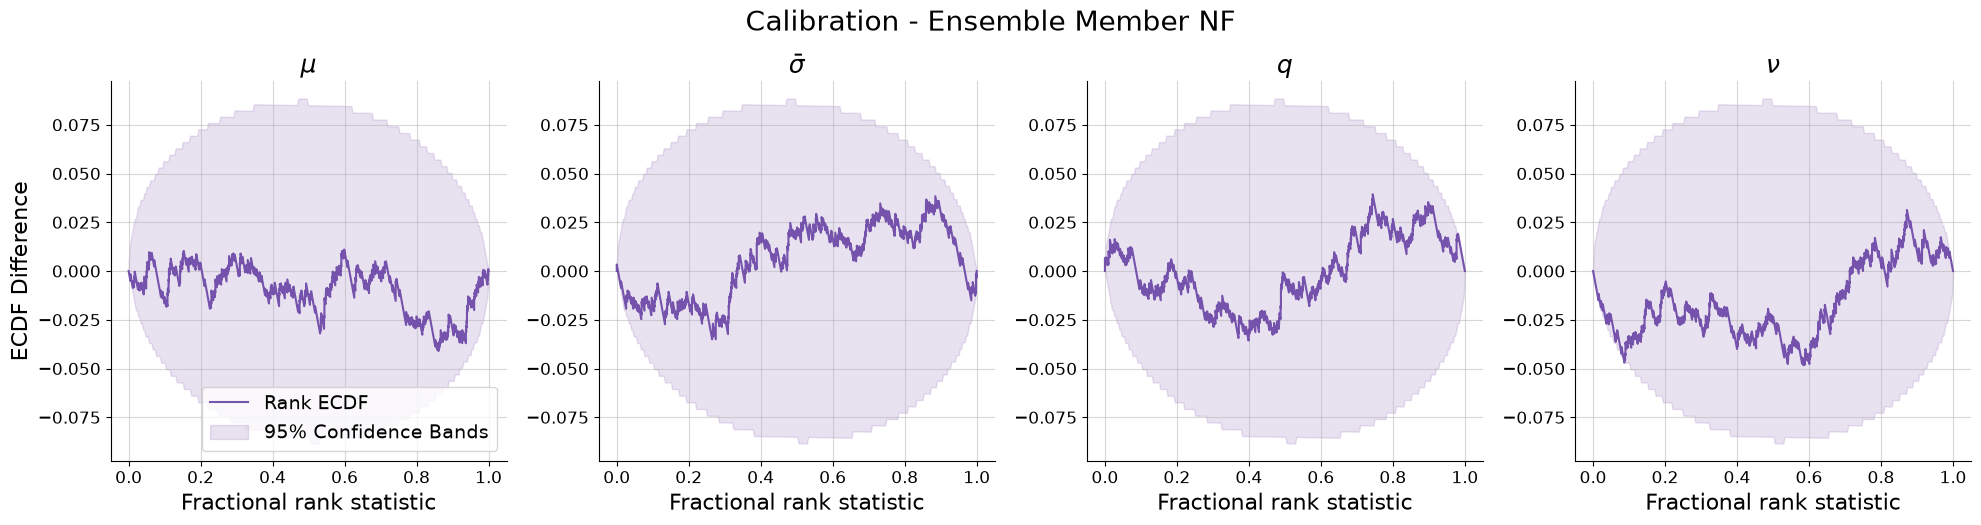

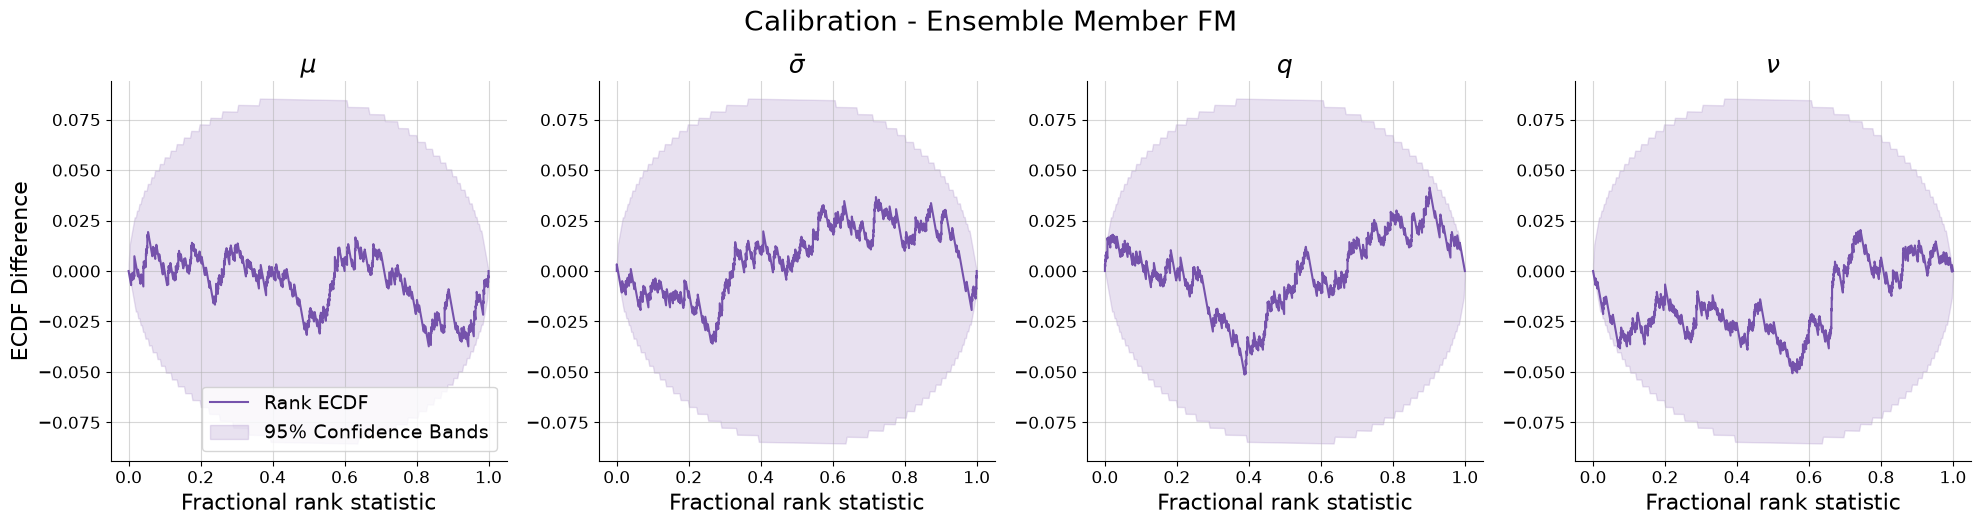

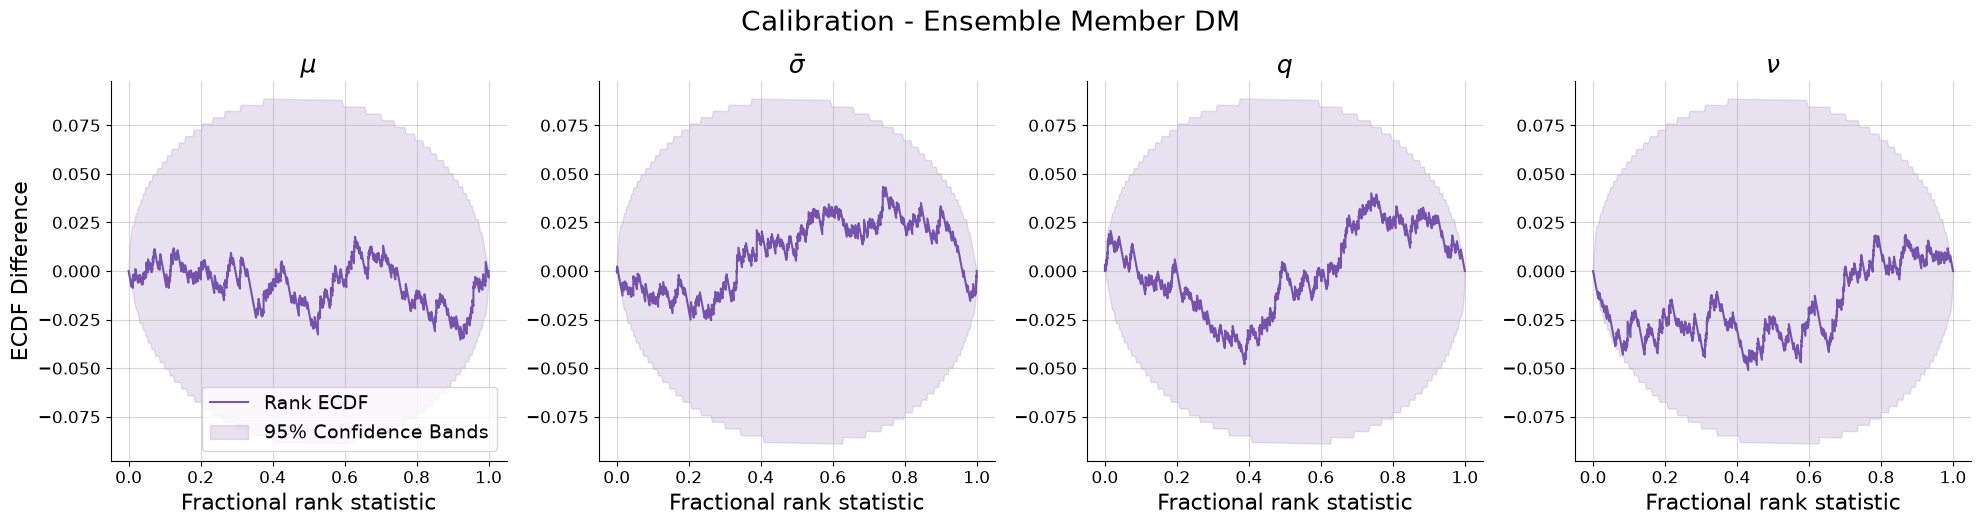

In [31]:
for k, v in samples.items():
    fig = bf.diagnostics.calibration_ecdf(
        estimates=samples[k],
        targets=test_simulations,
        uncertainty_agg_kwargs={"prob": 0.68},
        rank_ecdf_color=viz.PREDICTION_PURPLE,
        fill_color=viz.CALIBRATION_BAND_COLOR,
        variable_names=model.PARAMETER_LABELS
    )
    fig.suptitle(f"Calibration - Ensemble Member {k.upper()}", fontsize=20, y=1.05)

## 9. What the baseline establishes

The univariate workflow showcases that the drift, baseline scale, cascade intermittency, and Student-$t$ tail thickness can be recovered with a reasonable accuracy. The [next notebook](./mmar_stock_screener.ipynb) loads that saved estimator once and applies the same four-parameter model independently across the S&P 500 universe.